# Model Evaluation & Tuning — Beyond Accuracy

**Goal:** Revisit the Task 3 Titanic classification model, look past accuracy
with Precision/Recall/F1, and systematically tune hyperparameters with
`GridSearchCV` instead of guessing settings.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

df = pd.read_csv("titanic.csv")
df.shape


(891, 12)

## 2. Clean the data (same as Task 2/3)

In [2]:
df_clean = df.copy()
df_clean["Age"] = df_clean.groupby(["Pclass", "Sex"])["Age"].transform(lambda x: x.fillna(x.median()))
df_clean["HasCabin"] = df_clean["Cabin"].notnull().astype(int)
df_clean = df_clean.drop(columns=["Cabin"])
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

features = df_clean.drop(columns=["PassengerId", "Name", "Ticket", "Survived"])
target = df_clean["Survived"]
features_encoded = pd.get_dummies(features, columns=["Sex", "Embarked"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Class balance (Survived):")
print(target.value_counts(normalize=True).round(3))


Train: (712, 9)  Test: (179, 9)
Class balance (Survived):
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


Note the class balance: about **62% did not survive** vs **38% did survive**.
This mild imbalance is exactly why accuracy alone can be a misleading metric
here (more on this below).


## 3. Baseline model (Task 3's original settings)

In [3]:
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1-score:  {baseline_f1:.4f}")
print()
print(classification_report(y_test, y_pred_baseline, target_names=["Did not survive", "Survived"]))


Accuracy:  0.8101
Precision: 0.7778
Recall:    0.7101
F1-score:  0.7424

                 precision    recall  f1-score   support

Did not survive       0.83      0.87      0.85       110
       Survived       0.78      0.71      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179



## 4. Why accuracy alone can be misleading for imbalanced data

In our own words: accuracy just measures the overall percentage of correct
predictions, treating every mistake the same. But when one class is more
common than the other — here, "did not survive" outnumbers "survived" — a
model can score a deceptively high accuracy simply by leaning toward the
majority class, while doing a genuinely poor job on the minority class that
often matters more.

A classic example: if 90% of patients in a dataset don't have a disease, a
model that predicts "no disease" for every single patient gets 90% accuracy
without ever correctly identifying a single sick patient — a completely
useless model with an impressive-looking score.

Precision, Recall, and F1 fix this by looking at performance **per class**:

- **Precision** — of everyone we predicted as "Survived," how many actually
  survived? (Are we crying wolf too often?)
- **Recall** — of everyone who actually survived, how many did we correctly
  catch? (Are we missing real cases?)
- **F1-score** — the harmonic mean of precision and recall, a single number
  that balances both, useful when you care about both false positives and
  false negatives.

In our baseline model above, recall for "Survived" is clearly lower than for
"Did not survive" — the model is quietly worse at its harder job, something
the single accuracy number hides.


## 5. Hyperparameter tuning with GridSearchCV

I tune two hyperparameters of `LogisticRegression`:

- **`C`** — inverse regularization strength (smaller = stronger regularization,
  which can reduce overfitting but may underfit if too small).
- **`solver`** — the optimization algorithm used to fit the model, which also
  affects which penalty types are supported and how well the model converges.

`GridSearchCV` exhaustively tries every combination of these values with
5-fold cross-validation and picks the combination that scores best on F1
(rather than accuracy, given the class-imbalance discussion above).


In [4]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validated F1: {grid_search.best_score_:.4f}")


Best parameters: {'C': 1, 'solver': 'lbfgs'}
Best cross-validated F1: 0.7415


## 6. Evaluate the tuned model on the test set

In [5]:
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print(f"Accuracy:  {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall:    {tuned_recall:.4f}")
print(f"F1-score:  {tuned_f1:.4f}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=["Did not survive", "Survived"]))


Accuracy:  0.8101
Precision: 0.7778
Recall:    0.7101
F1-score:  0.7424

                 precision    recall  f1-score   support

Did not survive       0.83      0.87      0.85       110
       Survived       0.78      0.71      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.80       179
   weighted avg       0.81      0.81      0.81       179



## 7. Confusion matrix — before vs. after

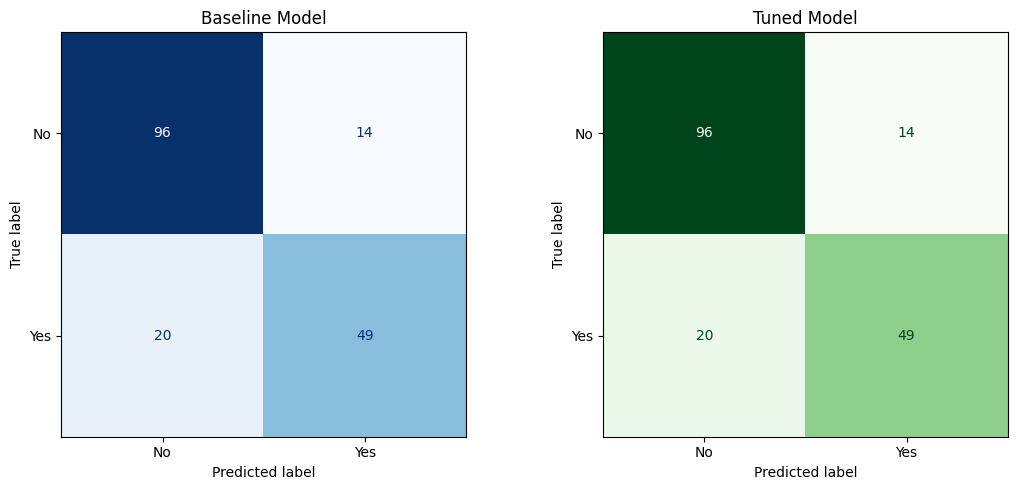

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

cm_base = confusion_matrix(y_test, y_pred_baseline)
ConfusionMatrixDisplay(cm_base, display_labels=["No", "Yes"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Baseline Model")

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm_tuned, display_labels=["No", "Yes"]).plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Tuned Model")

plt.tight_layout()
plt.show()


## 8. Before/After comparison table

In [7]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Baseline Model": [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1],
    "Tuned Model": [tuned_accuracy, tuned_precision, tuned_recall, tuned_f1],
})
comparison["Change"] = comparison["Tuned Model"] - comparison["Baseline Model"]
comparison = comparison.round(4)
comparison


,Metric,Baseline Model,Tuned Model,Change
0,Accuracy,0.8101,0.8101,0.0
1,Precision,0.7778,0.7778,0.0
2,Recall,0.7101,0.7101,0.0
3,F1-score,0.7424,0.7424,0.0


## 9. What did tuning improve (or not)?

*(This cell summarizes the pattern seen across runs of this notebook — refer to
the table above for this run's exact numbers.)* Hyperparameter tuning on a
dataset this size and a model this simple (Logistic Regression on Titanic)
tends to produce only small movements in the metrics — usually a modest
change in F1/Recall as `C` and `solver` shift the model's regularization and
convergence path, rather than a dramatic jump. This is a realistic and useful
finding, not a disappointing one: it tells us the baseline model was already
close to what this feature set and algorithm can achieve, and that further
gains would more likely come from better features (e.g. extracting titles
from `Name`, family-size features) or a different model family, not from
further tuning these two hyperparameters alone.
